
Mean allowed bases per position:
  Pos 1: 1.15
  Pos 2: 1.05
  Pos 3: 2.75

Pos 2 has exactly 1 allowed base for 19 / 20 AAs
Pos 3 has 4 allowed bases for 8 / 20 AAs


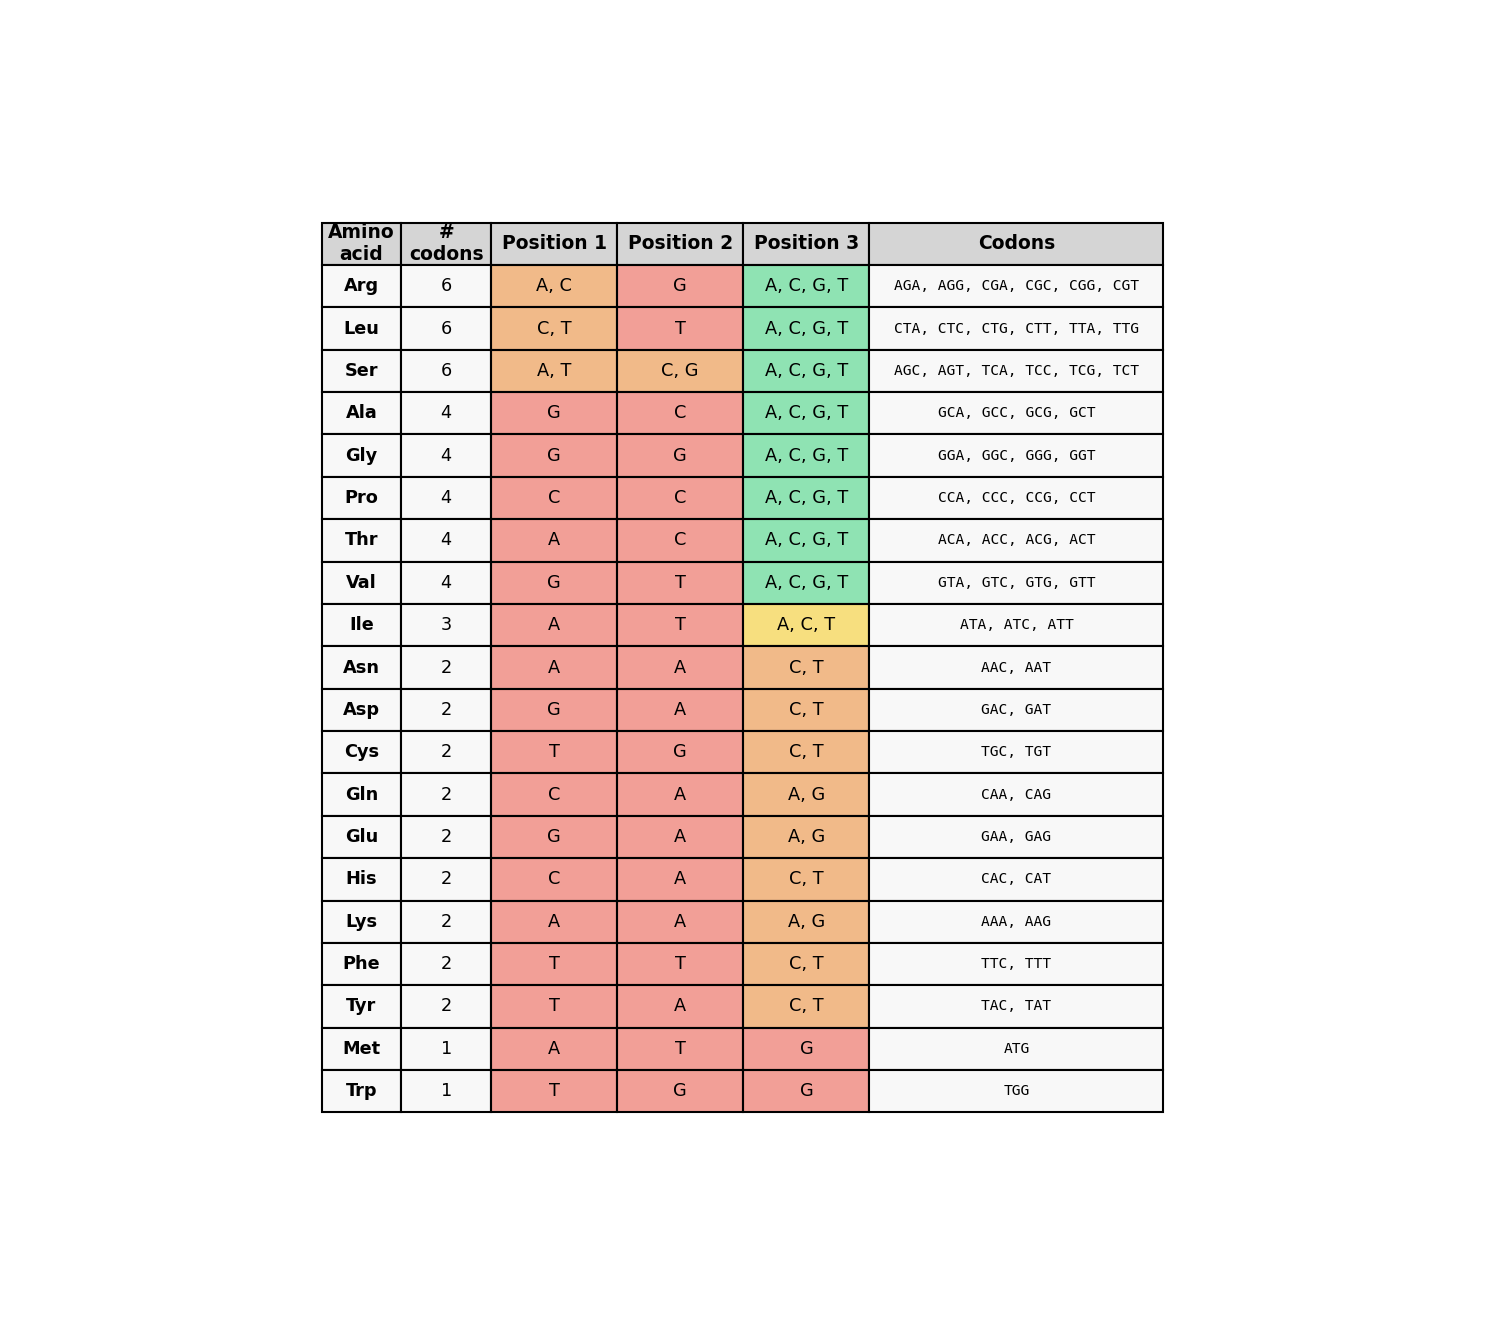

In [3]:
"""
Build a clear table showing, for each of the 20 amino acids,
which nucleotides are tolerated at each codon position.
This makes it visually obvious that pos 3 is highly degenerate
and pos 2 is completely rigid.
"""
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams.update({
    'font.size': 10,
    'figure.dpi': 150,
    'savefig.dpi': 150,
})

CODON_TABLE = {
    'TTT': 'Phe', 'TTC': 'Phe', 'TTA': 'Leu', 'TTG': 'Leu',
    'CTT': 'Leu', 'CTC': 'Leu', 'CTA': 'Leu', 'CTG': 'Leu',
    'ATT': 'Ile', 'ATC': 'Ile', 'ATA': 'Ile', 'ATG': 'Met',
    'GTT': 'Val', 'GTC': 'Val', 'GTA': 'Val', 'GTG': 'Val',
    'TCT': 'Ser', 'TCC': 'Ser', 'TCA': 'Ser', 'TCG': 'Ser',
    'CCT': 'Pro', 'CCC': 'Pro', 'CCA': 'Pro', 'CCG': 'Pro',
    'ACT': 'Thr', 'ACC': 'Thr', 'ACA': 'Thr', 'ACG': 'Thr',
    'GCT': 'Ala', 'GCC': 'Ala', 'GCA': 'Ala', 'GCG': 'Ala',
    'TAT': 'Tyr', 'TAC': 'Tyr', 'TAA': '*',   'TAG': '*',
    'TGT': 'Cys', 'TGC': 'Cys', 'TGA': '*',   'TGG': 'Trp',
    'CAT': 'His', 'CAC': 'His', 'CAA': 'Gln', 'CAG': 'Gln',
    'AAT': 'Asn', 'AAC': 'Asn', 'AAA': 'Lys', 'AAG': 'Lys',
    'CGT': 'Arg', 'CGC': 'Arg', 'CGA': 'Arg', 'CGG': 'Arg',
    'AGT': 'Ser', 'AGC': 'Ser', 'AGA': 'Arg', 'AGG': 'Arg',
    'GAT': 'Asp', 'GAC': 'Asp', 'GAA': 'Glu', 'GAG': 'Glu',
    'GGT': 'Gly', 'GGC': 'Gly', 'GGA': 'Gly', 'GGG': 'Gly',
}

BASES = list('ACGT')
NON_STOP = {c: aa for c, aa in CODON_TABLE.items() if aa != '*'}

# For each AA, find the set of allowed bases at each position
aa_codons = {}
for codon, aa in NON_STOP.items():
    aa_codons.setdefault(aa, []).append(codon)

# Sort AAs by number of codons (descending), then alphabetically
aa_list = sorted(aa_codons.keys(), key=lambda a: (-len(aa_codons[a]), a))

# Build the data: for each AA and each position, which bases appear?
rows = []
for aa in aa_list:
    codons = aa_codons[aa]
    pos_bases = []
    for pos in range(3):
        bases_at_pos = sorted(set(c[pos] for c in codons))
        pos_bases.append(bases_at_pos)
    rows.append((aa, len(codons), pos_bases))

# ── Figure: table with colour-coded cells ──
fig, ax = plt.subplots(figsize=(10, 9))
ax.axis('off')

# Header
col_labels = ['Amino\nacid', '#\ncodons', 'Position 1', 'Position 2', 'Position 3', 'Codons']
n_rows = len(rows)
n_cols = len(col_labels)

# Colour map: number of allowed bases → colour
# 1 base = very rigid (red), 2 = constrained (orange), 3 = flexible (yellow), 4 = fully degenerate (green)
cmap = {1: '#e74c3c', 2: '#e67e22', 3: '#f1c40f', 4: '#2ecc71'}
cmap_text = {1: 'white', 2: 'white', 3: 'black', 4: 'white'}

cell_text = []
cell_colours = []

for aa, n_cod, pos_bases in rows:
    row_text = [aa, str(n_cod)]
    row_colours = ['#f8f8f8', '#f8f8f8']
    for pos in range(3):
        bases = pos_bases[pos]
        n = len(bases)
        row_text.append(', '.join(bases))
        row_colours.append(cmap[n] + '88')  # with alpha via hex
    row_text.append(', '.join(sorted(aa_codons[aa])))
    row_colours.append('#f8f8f8')
    cell_text.append(row_text)
    cell_colours.append(row_colours)

tbl = ax.table(cellText=cell_text, colLabels=col_labels,
               cellColours=cell_colours,
               colColours=['#d5d5d5']*n_cols,
               loc='center', cellLoc='center')

tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.auto_set_column_width(list(range(n_cols)))
tbl.scale(1.0, 1.35)

# Bold header
for j in range(n_cols):
    tbl[0, j].set_text_props(fontweight='bold', fontsize=9)

# Left-align codons column
for i in range(1, n_rows + 1):
    tbl[i, 5].set_text_props(fontfamily='monospace', fontsize=7)
    tbl[i, 0].set_text_props(fontweight='bold')


# Summary stats at bottom
pos_avg = []
for pos in range(3):
    all_n = [len(r[2][pos]) for r in rows]
    pos_avg.append(np.mean(all_n))


plt.tight_layout()


# Print summary
print(f"\nMean allowed bases per position:")
print(f"  Pos 1: {pos_avg[0]:.2f}")
print(f"  Pos 2: {pos_avg[1]:.2f}")
print(f"  Pos 3: {pos_avg[2]:.2f}")
print(f"\nPos 2 has exactly 1 allowed base for {sum(1 for r in rows if len(r[2][1])==1)} / {len(rows)} AAs")
print(f"Pos 3 has 4 allowed bases for {sum(1 for r in rows if len(r[2][2])==4)} / {len(rows)} AAs")

FRAME 1 STOP-CODON CONSTRAINT PROOF

1. Stop codons and their reverse complements:

   TAA (stop)  →  rc = TTA  (ends with A)
   TAG (stop)  →  rc = CTA  (ends with A)
   TGA (stop)  →  rc = TCA  (ends with A)

   ✓ All reverse complements end with A

2. Dangerous boundary dinucleotides (pos 2–3 of gene 1 codon):

   ...X[CT] | [A]... → gene 2 reads rc = TAG (STOP)
   ...X[TC] | [A]... → gene 2 reads rc = TGA (STOP)
   ...X[TT] | [A]... → gene 2 reads rc = TAA (STOP)

3. Affected codons: 12 / 61 (20%)

4. Codons starting with A: 16 / 61
   Remaining if A-start blocked: 45

5. Amino acids encoded ONLY by A-starting codons (inaccessible):
   Asn, Ile, Lys, Met, Thr  (5 amino acids)


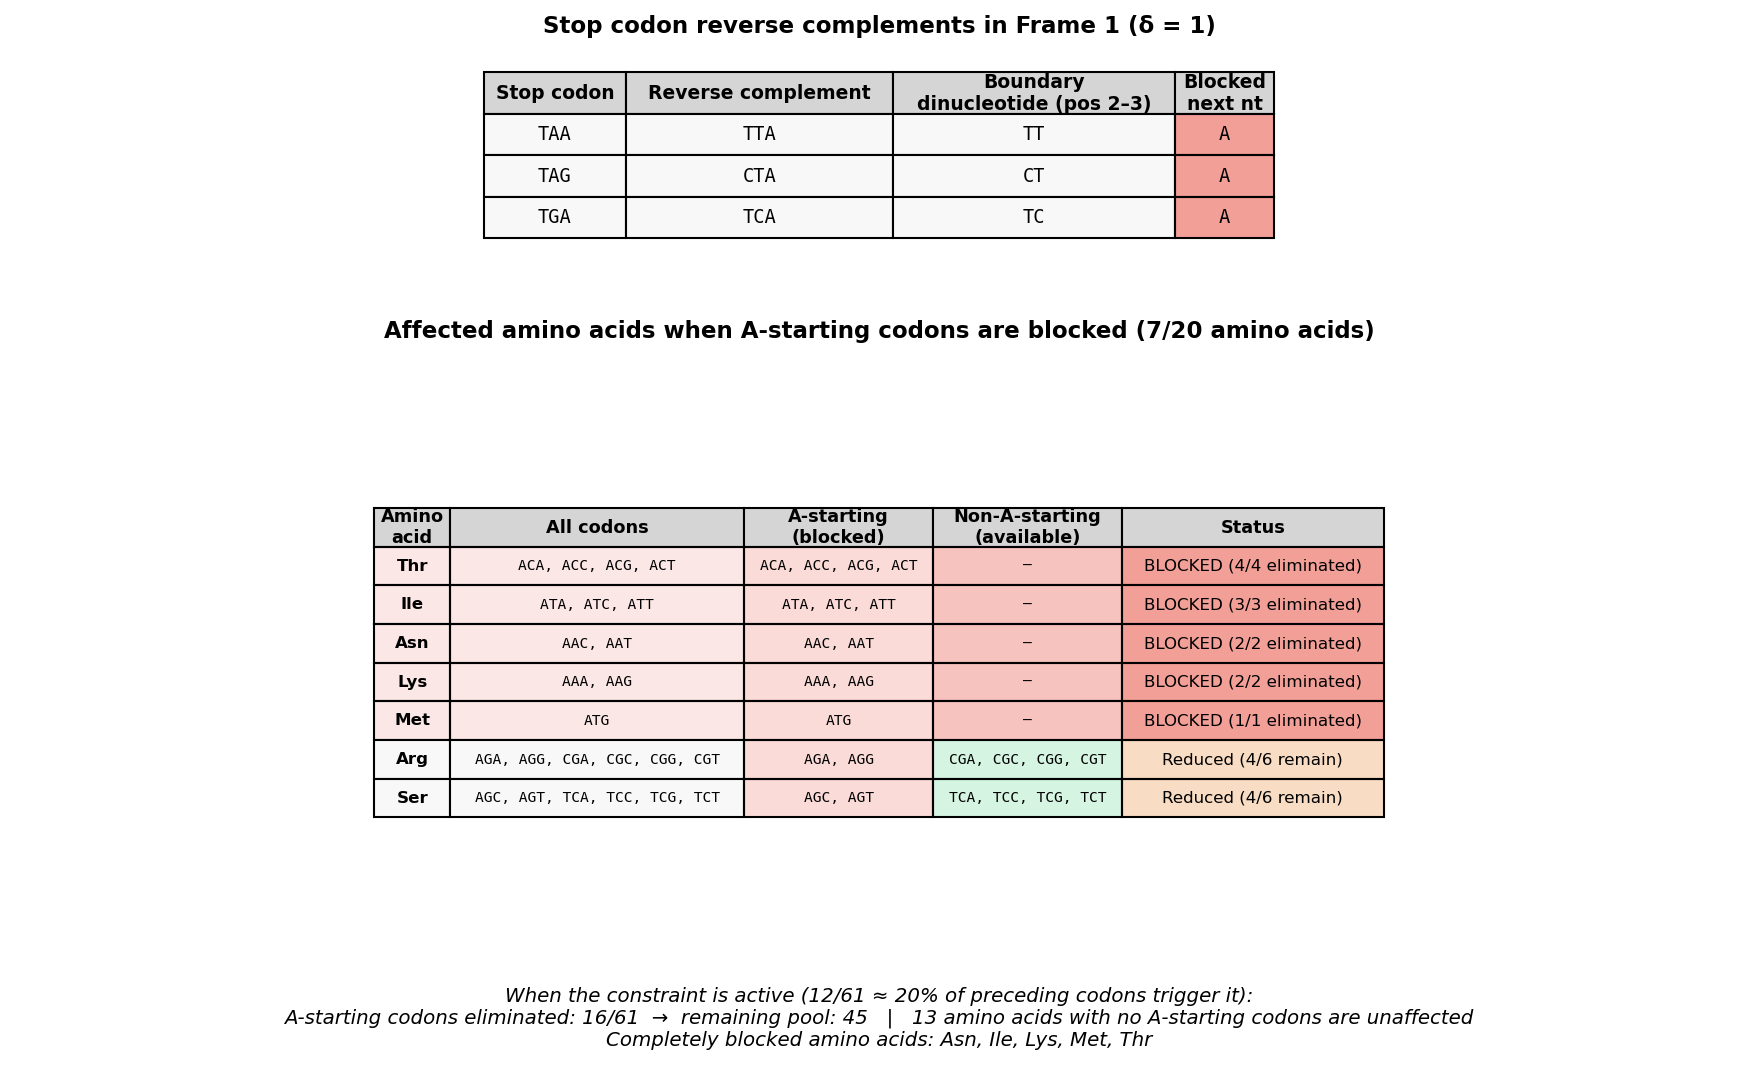


Saved frame1_stop_codon_constraint.png


In [4]:
"""
Frame 1 (δ=1) stop-codon constraint proof.

In Frame 1 the reverse-strand gene 2 reads codons from positions
(n2, n3, n4) as (rc(n4), rc(n3), rc(n2)).  So a stop codon in gene 2
arises when:
    TAA  →  n2=T, n3=T, n4=A   (boundary dinucleotide TT)
    TAG  →  n2=C, n3=T, n4=A   (boundary dinucleotide CT)
    TGA  →  n2=T, n3=C, n4=A   (boundary dinucleotide TC)

If positions 2–3 of a gene 1 codon form TT, CT, or TC, the *next*
gene 1 codon cannot begin with A — eliminating all 16 A-starting codons
and making 5 amino acids (Ile, Lys, Met, Asn, Thr) inaccessible.
"""
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
from collections import defaultdict

matplotlib.rcParams.update({
    'font.size': 10,
    'figure.dpi': 150,
    'savefig.dpi': 150,
})

CODON_TABLE = {
    'TTT': 'Phe', 'TTC': 'Phe', 'TTA': 'Leu', 'TTG': 'Leu',
    'CTT': 'Leu', 'CTC': 'Leu', 'CTA': 'Leu', 'CTG': 'Leu',
    'ATT': 'Ile', 'ATC': 'Ile', 'ATA': 'Ile', 'ATG': 'Met',
    'GTT': 'Val', 'GTC': 'Val', 'GTA': 'Val', 'GTG': 'Val',
    'TCT': 'Ser', 'TCC': 'Ser', 'TCA': 'Ser', 'TCG': 'Ser',
    'CCT': 'Pro', 'CCC': 'Pro', 'CCA': 'Pro', 'CCG': 'Pro',
    'ACT': 'Thr', 'ACC': 'Thr', 'ACA': 'Thr', 'ACG': 'Thr',
    'GCT': 'Ala', 'GCC': 'Ala', 'GCA': 'Ala', 'GCG': 'Ala',
    'TAT': 'Tyr', 'TAC': 'Tyr', 'TAA': '*',   'TAG': '*',
    'TGT': 'Cys', 'TGC': 'Cys', 'TGA': '*',   'TGG': 'Trp',
    'CAT': 'His', 'CAC': 'His', 'CAA': 'Gln', 'CAG': 'Gln',
    'AAT': 'Asn', 'AAC': 'Asn', 'AAA': 'Lys', 'AAG': 'Lys',
    'CGT': 'Arg', 'CGC': 'Arg', 'CGA': 'Arg', 'CGG': 'Arg',
    'AGT': 'Ser', 'AGC': 'Ser', 'AGA': 'Arg', 'AGG': 'Arg',
    'GAT': 'Asp', 'GAC': 'Asp', 'GAA': 'Glu', 'GAG': 'Glu',
    'GGT': 'Gly', 'GGC': 'Gly', 'GGA': 'Gly', 'GGG': 'Gly',
}

RC = {'A': 'T', 'T': 'A', 'C': 'G', 'G': 'C'}
NON_STOP = {c: aa for c, aa in CODON_TABLE.items() if aa != '*'}
STOP_CODONS = [c for c, aa in CODON_TABLE.items() if aa == '*']

# ── Part 1: derive the dangerous dinucleotides from first principles ──
dangerous_di = {}
for stop in STOP_CODONS:
    n2 = RC[stop[2]]
    n3 = RC[stop[1]]
    n4 = RC[stop[0]]
    di = n2 + n3
    dangerous_di[di] = (stop, n4)

# ── Part 2: find affected gene 1 codons ──
affected_codons = {}
for codon, aa in NON_STOP.items():
    di = codon[1] + codon[2]
    if di in dangerous_di:
        stop, _ = dangerous_di[di]
        affected_codons[codon] = (aa, di, stop)

n_affected = len(affected_codons)

# ── Part 3: for each amino acid, count A-starting vs non-A-starting codons ──
aa_codons_all = defaultdict(list)
for c, aa in NON_STOP.items():
    aa_codons_all[aa].append(c)

aa_a_start = {}
aa_non_a_start = {}
for aa, codons in aa_codons_all.items():
    aa_a_start[aa] = sorted([c for c in codons if c[0] == 'A'])
    aa_non_a_start[aa] = sorted([c for c in codons if c[0] != 'A'])

a_codons = {c: aa for c, aa in NON_STOP.items() if c[0] == 'A'}
non_a_codons = {c: aa for c, aa in NON_STOP.items() if c[0] != 'A'}
all_aas = set(NON_STOP.values())
aas_without_a = set(non_a_codons.values())
inaccessible_aas = sorted(all_aas - aas_without_a)

# ── Print verification ──
print("="*65)
print("FRAME 1 STOP-CODON CONSTRAINT PROOF")
print("="*65)

print("\n1. Stop codons and their reverse complements:\n")
for stop in STOP_CODONS:
    rc_seq = ''.join(RC[b] for b in reversed(stop))
    print(f"   {stop} (stop)  →  rc = {rc_seq}  (ends with {rc_seq[-1]})")
print(f"\n   ✓ All reverse complements end with A")

print(f"\n2. Dangerous boundary dinucleotides (pos 2–3 of gene 1 codon):\n")
for di, (stop, forced_next) in sorted(dangerous_di.items()):
    print(f"   ...X[{di}] | [A]... → gene 2 reads rc = {stop} (STOP)")

print(f"\n3. Affected codons: {n_affected} / {len(NON_STOP)} "
      f"({100*n_affected/len(NON_STOP):.0f}%)")

print(f"\n4. Codons starting with A: {len(a_codons)} / {len(NON_STOP)}")
print(f"   Remaining if A-start blocked: {len(NON_STOP) - len(a_codons)}")

print(f"\n5. Amino acids encoded ONLY by A-starting codons (inaccessible):")
print(f"   {', '.join(inaccessible_aas)}  ({len(inaccessible_aas)} amino acids)")

# ── Figure: summary tables ──
# Only include AAs that have at least one A-starting codon
affected_aas = [aa for aa in aa_codons_all if len(aa_a_start[aa]) > 0]
affected_aas.sort(key=lambda a: (-len(aa_a_start[a]) / len(aa_codons_all[a]),
                                  -len(aa_a_start[a]), a))

fig, axes = plt.subplots(2, 1, figsize=(12, 7),
                         gridspec_kw={'height_ratios': [1, 3]})

# --- Top table: stop codon → reverse complement → dangerous dinucleotide ---
ax0 = axes[0]
ax0.axis('off')
ax0.set_title('Stop codon reverse complements in Frame 1 (δ = 1)',
              fontsize=11, fontweight='bold', pad=10)

top_headers = ['Stop codon', 'Reverse complement', 'Boundary\ndinucleotide (pos 2–3)',
               'Blocked\nnext nt']
top_data = []
for stop in STOP_CODONS:
    rc_seq = ''.join(RC[b] for b in reversed(stop))
    di = rc_seq[0] + rc_seq[1]
    top_data.append([stop, rc_seq, di, 'A'])

top_colours = [['#f8f8f8']*4 for _ in range(3)]
for i in range(3):
    top_colours[i][3] = '#e74c3c88'

tbl0 = ax0.table(cellText=top_data, colLabels=top_headers,
                 cellColours=top_colours,
                 colColours=['#d5d5d5']*4,
                 loc='center', cellLoc='center')
tbl0.auto_set_font_size(False)
tbl0.set_fontsize(9)
tbl0.auto_set_column_width(list(range(4)))
tbl0.scale(1.0, 1.5)
for j in range(4):
    tbl0[0, j].set_text_props(fontweight='bold', fontsize=9)
for i in range(1, 4):
    for j in range(4):
        tbl0[i, j].set_text_props(fontfamily='monospace')

# --- Bottom table: only AAs with at least one A-starting codon ---
ax1 = axes[1]
ax1.axis('off')
ax1.set_title(f'Affected amino acids when A-starting codons are blocked '
              f'({len(affected_aas)}/20 amino acids)',
              fontsize=11, fontweight='bold', pad=10)

bot_headers = ['Amino\nacid', 'All codons', 'A-starting\n(blocked)',
               'Non-A-starting\n(available)', 'Status']

bot_data = []
bot_colours = []
for aa in affected_aas:
    all_codons = sorted(aa_codons_all[aa])
    a_start = aa_a_start[aa]
    non_a = aa_non_a_start[aa]

    all_str = ', '.join(all_codons)
    a_str = ', '.join(a_start)
    non_a_str = ', '.join(non_a) if non_a else '—'

    fully_blocked = len(non_a) == 0
    if fully_blocked:
        status = f'BLOCKED ({len(a_start)}/{len(all_codons)} eliminated)'
        status_col = '#e74c3c88'
        row_bg = '#e74c3c22'
    else:
        status = f'Reduced ({len(non_a)}/{len(all_codons)} remain)'
        status_col = '#e67e2244'
        row_bg = '#f8f8f8'

    bot_data.append([aa, all_str, a_str, non_a_str, status])
    bot_colours.append([row_bg, row_bg, '#e74c3c33',
                        '#2ecc7133' if non_a else '#e74c3c55', status_col])

tbl1 = ax1.table(cellText=bot_data, colLabels=bot_headers,
                 cellColours=bot_colours,
                 colColours=['#d5d5d5']*5,
                 loc='center', cellLoc='center')
tbl1.auto_set_font_size(False)
tbl1.set_fontsize(8)
tbl1.auto_set_column_width(list(range(5)))
tbl1.scale(1.0, 1.4)
for j in range(5):
    tbl1[0, j].set_text_props(fontweight='bold', fontsize=8.5)
for i in range(1, len(bot_data) + 1):
    tbl1[i, 0].set_text_props(fontweight='bold')
    for j in [1, 2, 3]:
        tbl1[i, j].set_text_props(fontfamily='monospace', fontsize=7)

# Bottom annotation
n_unaffected = 20 - len(affected_aas)
summary_text = (
    f"When the constraint is active ({n_affected}/61 ≈ {100*n_affected/len(NON_STOP):.0f}% "
    f"of preceding codons trigger it):\n"
    f"A-starting codons eliminated: {len(a_codons)}/61  →  "
    f"remaining pool: {len(NON_STOP) - len(a_codons)}   |   "
    f"{n_unaffected} amino acids with no A-starting codons are unaffected\n"
    f"Completely blocked amino acids: {', '.join(inaccessible_aas)}"
)
fig.text(0.5, 0.005, summary_text, ha='center', fontsize=9.5, fontstyle='italic')

fig.subplots_adjust(left=0.02, right=0.98, top=0.95, bottom=0.08, hspace=0.25)
plt.savefig('frame1_stop_codon_constraint.png', bbox_inches='tight', pad_inches=0.1)
plt.show()
print("\nSaved frame1_stop_codon_constraint.png")